# Phase 1 : การตรวจสอบคุณภาพข้อมูล (Data Quality Check)

**วัตถุประสงค์:** ตรวจสอบและรับรองคุณภาพของข้อมูล OHLCV ดิบที่ดึงมาจาก tvkit ก่อนเริ่มการ Research Signal ใน Phase 2  
**ข้อกำหนด:**  ต้องผ่านทุกเกณฑ์ใน Section 7 (Sign-off) จึงจะถือว่า Phase 1 เสร็จสมบูรณ์

**แหล่งข้อมูล:**
- `data/raw/` — ไฟล์ parquet ดิบสำหรับแต่ละ symbol (ผลลัพธ์จาก `fetch_history.py`)
- `data/universe/symbols.json` — รายชื่อ symbol ทั้งหมดใน SET (ผลลัพธ์จาก `build_universe.py`)
- `data/universe/universe/{YYYY-MM-DD}.parquet` — snapshot universe รายเดือน

**วิธีใช้:** Run ทุก cell ตามลำดับ หากข้อมูลยังไม่ถูกดึง (data/raw/ ว่างเปล่า) แต่ละ section จะแสดงข้อความ `⚠ DATA NOT AVAILABLE` และข้ามไป

**หมายเหตุ:** ต้อง Fetch ข้อมูลราคา OHLCV ย้อนหลังก่อน โดยใช้ tvkit

In [ ]:
# Setup — imports, paths, stores, inventory
import json
import os
import sys
import warnings
from pathlib import Path

# Anchor CWD to project root (works whether invoked from project root or notebooks/)
_HERE = Path.cwd()
_PROJECT_ROOT = _HERE.parent if _HERE.name == "notebooks" else _HERE
os.chdir(_PROJECT_ROOT)

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

sys.path.insert(0, str(_PROJECT_ROOT / "src"))

from csm.config.constants import LOOKBACK_YEARS, MIN_AVG_DAILY_VOLUME, MIN_DATA_COVERAGE
from csm.config.settings import Settings
from csm.data.store import ParquetStore

# Suppress warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, message=".*Glyph.*missing from font.*")

# Fix Thai font — scan registered fonts for Thai character support
_available_fonts: set[str] = {f.name for f in fm.fontManager.ttflist}
_thai_candidates: list[str] = ["Thonburi", "Arial Unicode MS", "Noto Sans Thai", "Noto Sans", "Tahoma"]
_thai_font: str | None = next((f for f in _thai_candidates if f in _available_fonts), None)
if _thai_font:
    plt.rcParams["font.family"] = [_thai_font, "DejaVu Sans"]

settings = Settings()

# Phase 1.8: data/raw/ is now split into adjustment-scoped subdirectories.
# Prefer data/raw/splits/ (Phase 1.6 legacy data after migration); fall back to
# data/raw/ directly for repositories that have not yet run the migration.
_splits_path = settings.data_dir / "raw" / "splits"
_legacy_path = settings.data_dir / "raw"
_raw_path = _splits_path if _splits_path.exists() and any(_splits_path.glob("*.parquet")) else _legacy_path

raw_store = ParquetStore(_raw_path)
universe_store = ParquetStore(settings.data_dir / "universe")

symbol_keys: list[str] = raw_store.list_keys()
snapshot_keys: list[str] = [
    k for k in universe_store.list_keys() if k.startswith("universe/")
]

display(HTML(f"""
<table style="border-collapse:collapse;font-size:14px;font-family:monospace;">
  <tr style="background:#f5f5f5">
    <th style="text-align:left;padding:6px 24px 6px 8px;color:#555;">Setting</th>
    <th style="text-align:left;padding:6px 8px;">Value</th>
  </tr>
  <tr><td style="padding:5px 24px 5px 8px;color:#888;">Raw store path</td><td style="padding:5px 8px;font-weight:bold;">{_raw_path}</td></tr>
  <tr style="background:#fafafa"><td style="padding:5px 24px 5px 8px;color:#888;">Raw symbol parquets found</td><td style="padding:5px 8px;font-weight:bold;">{len(symbol_keys)}</td></tr>
  <tr><td style="padding:5px 24px 5px 8px;color:#888;">Universe snapshots found</td><td style="padding:5px 8px;font-weight:bold;">{len(snapshot_keys)}</td></tr>
  <tr style="background:#fafafa"><td style="padding:5px 24px 5px 8px;color:#888;">Settings.data_dir</td><td style="padding:5px 8px;font-weight:bold;">{settings.data_dir}</td></tr>
  <tr><td style="padding:5px 24px 5px 8px;color:#888;">LOOKBACK_YEARS</td><td style="padding:5px 8px;font-weight:bold;">{LOOKBACK_YEARS}</td></tr>
  <tr style="background:#fafafa"><td style="padding:5px 24px 5px 8px;color:#888;">MIN_DATA_COVERAGE</td><td style="padding:5px 8px;font-weight:bold;">{MIN_DATA_COVERAGE}</td></tr>
  <tr><td style="padding:5px 24px 5px 8px;color:#888;">MIN_AVG_DAILY_VOLUME</td><td style="padding:5px 8px;font-weight:bold;">{MIN_AVG_DAILY_VOLUME:,.0f} THB</td></tr>
  <tr style="background:#fafafa"><td style="padding:5px 24px 5px 8px;color:#888;">Thai font</td><td style="padding:5px 8px;font-weight:bold;">{_thai_font or "not found — glyph warnings suppressed"}</td></tr>
</table>
"""))

## ส่วนที่ 1: Missing Data Heatmap

แสดงสัดส่วนของข้อมูลที่ขาดหายไปในแต่ละปีสำหรับแต่ละ symbol (แกน x = symbol, แกน y = ปี)  
สีแดงหมายถึงข้อมูลขาดหายมาก สีเขียวหมายถึงข้อมูลครบถ้วน  
ใช้สำหรับระบุ gap ที่เกิดจากการหยุดซื้อขายหรือปัญหาการดึงข้อมูล

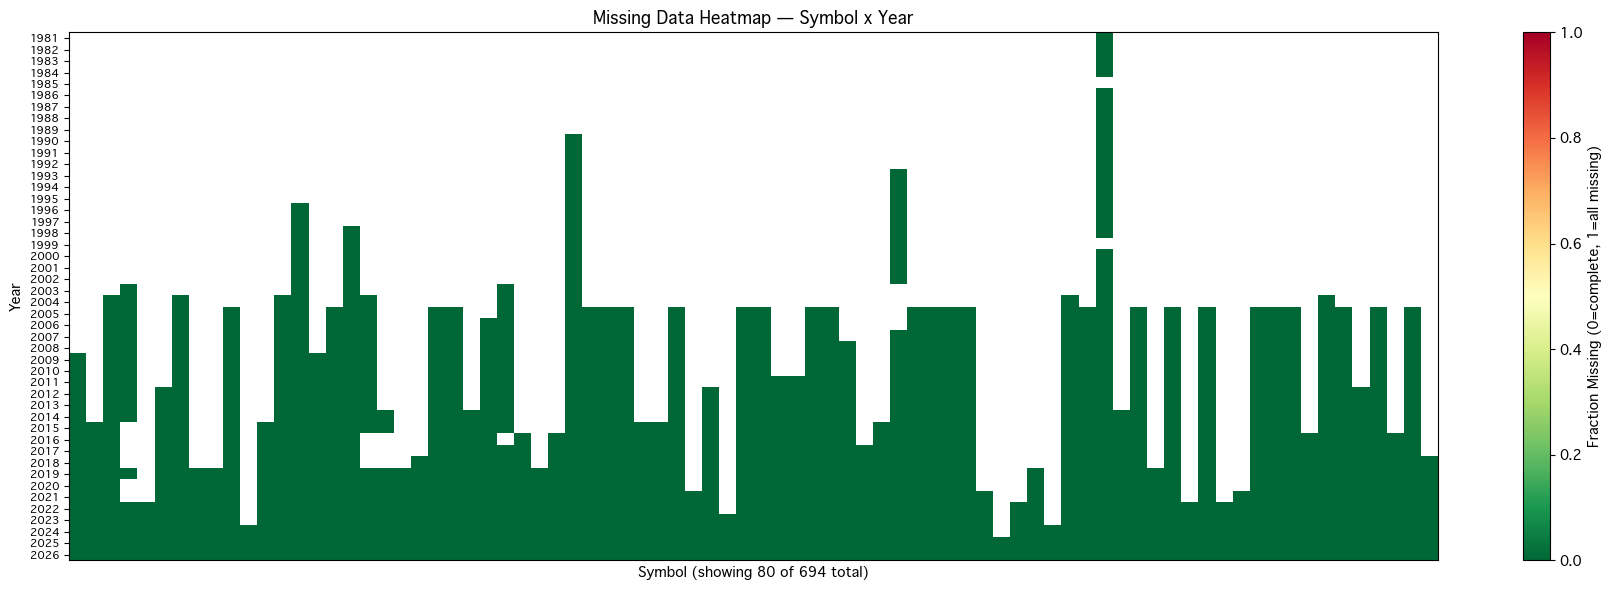

In [2]:
# Section 1 — Missing data heatmap
if not symbol_keys:
    display(HTML("<div style='color:orange;font-weight:bold;'>⚠ DATA NOT AVAILABLE — data/raw/ is empty. Run fetch_history.py first.</div>"))
else:
    # Load close series for each symbol and compute fraction missing per calendar year
    missing_data: dict[str, dict[int, float]] = {}
    for key in symbol_keys:
        try:
            df = raw_store.load(key)
            close = df["close"].copy()
            close.index = pd.DatetimeIndex(close.index).tz_localize(None)
            annual = close.resample("YE").apply(lambda s: s.isna().mean())
            missing_data[key] = {int(ts.year): float(v) for ts, v in annual.items()}
        except Exception:
            missing_data[key] = {}

    all_years = sorted({yr for v in missing_data.values() for yr in v})
    # Limit to first 80 symbols for readable x-axis
    display_keys = symbol_keys[:80]
    matrix = np.array(
        [[missing_data.get(k, {}).get(yr, np.nan) for k in display_keys] for yr in all_years]
    )

    fig, ax = plt.subplots(figsize=(18, 6))
    im = ax.imshow(matrix, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=1,
                   interpolation="nearest")
    plt.colorbar(im, ax=ax, label="Fraction Missing (0=complete, 1=all missing)")
    ax.set_yticks(range(len(all_years)))
    ax.set_yticklabels(all_years, fontsize=8)
    ax.set_xticks([])
    ax.set_xlabel(f"Symbol (showing {len(display_keys)} of {len(symbol_keys)} total)")
    ax.set_ylabel("Year")
    ax.set_title("Missing Data Heatmap — Symbol x Year")
    plt.tight_layout()
    plt.show()

    missing_count = sum(1 for v in missing_data.values() if any(f > 0 for f in v.values()))
    display(HTML(
        f"<span style='font-size:14px;'><b>Symbols with any missing data:</b> "
        f"<span style='color:#e74c3c;font-weight:bold;'>{missing_count}</span>"
        f" / {len(symbol_keys)}</span>"
    ))


## ส่วนที่ 2: การกระจายของผลตอบแทนรายปี (Cross-Sectional)

สำหรับแต่ละปี คำนวณผลตอบแทนต่อปีของแต่ละ symbol (`ราคาปิดวันสุดท้าย / ราคาปิดวันแรก − 1`)  
Box plot แสดงการกระจายของผลตอบแทนข้ามทุก symbol ในแต่ละปี (cross-sectional distribution)  
ไม่ใช่ time-series ของผลตอบแทนรายวัน  
Symbol ที่มีข้อมูลน้อยกว่า 20 วันในปีนั้นจะถูกตัดออกเพื่อป้องกันผลตอบแทนที่ผิดปกติ

/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_24831/2856531717.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_year, labels=years, patch_artist=True,


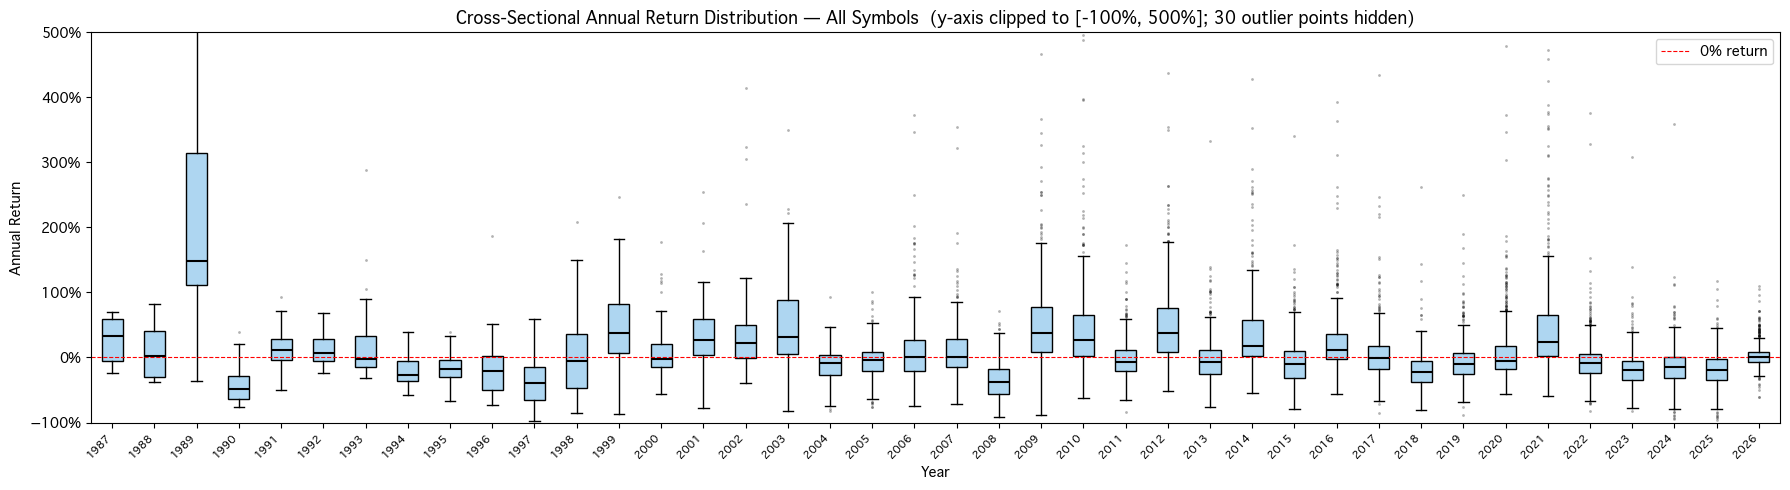

Total symbol-year observations,"11,806"
Year with most data,2025 (689 symbols)
Outliers clipped from view (outside -100%–500%),30


In [3]:
# Section 2 — Annual cross-sectional return distribution
if not symbol_keys:
    display(HTML("<div style='color:orange;font-weight:bold;'>⚠ DATA NOT AVAILABLE — data/raw/ is empty. Run fetch_history.py first.</div>"))
else:
    annual_returns_by_year: dict[int, list[float]] = {}
    for key in symbol_keys:
        try:
            df = raw_store.load(key)
            close = df["close"].dropna().copy()
            close.index = pd.DatetimeIndex(close.index).tz_localize(None)
            # Group by calendar year; compute first/last valid close per year
            for yr, grp in close.groupby(close.index.year):
                if len(grp) < 20:
                    continue
                first_val = float(grp.iloc[0])
                last_val = float(grp.iloc[-1])
                if first_val <= 0:
                    continue
                ret = (last_val / first_val) - 1.0
                annual_returns_by_year.setdefault(int(yr), []).append(ret)
        except Exception:
            continue

    years = sorted(annual_returns_by_year)
    data_by_year = [annual_returns_by_year[yr] for yr in years]

    Y_MAX = 5.0   # clip display at +500%
    Y_MIN = -1.0  # clip display at -100%

    # Count clipped outliers for annotation
    n_clipped = sum(
        1 for rets in data_by_year for r in rets if r > Y_MAX or r < Y_MIN
    )

    fig, ax = plt.subplots(figsize=(18, 5))
    bp = ax.boxplot(data_by_year, labels=years, patch_artist=True,
                    medianprops=dict(color="black", linewidth=1.5),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    for patch in bp["boxes"]:
        patch.set_facecolor("#AED6F1")
    ax.axhline(0, color="red", linewidth=0.8, linestyle="--", label="0% return")
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_xticklabels(years, rotation=45, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual Return")
    ax.set_title(
        f"Cross-Sectional Annual Return Distribution — All Symbols"
        f"  (y-axis clipped to [{Y_MIN:.0%}, {Y_MAX:.0%}]; {n_clipped:,} outlier points hidden)"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

    total_obs = sum(len(v) for v in data_by_year)
    best_yr_idx = int(np.argmax([len(v) for v in data_by_year]))
    best_yr = years[best_yr_idx]
    best_cnt = max(len(v) for v in data_by_year)
    display(HTML(f"""
<table style="border-collapse:collapse;font-size:14px;font-family:monospace;">
  <tr><td style="padding:4px 24px 4px 0;color:#888;">Total symbol-year observations</td>
      <td style="padding:4px 0;font-weight:bold;">{total_obs:,}</td></tr>
  <tr><td style="padding:4px 24px 4px 0;color:#888;">Year with most data</td>
      <td style="padding:4px 0;font-weight:bold;">{best_yr} ({best_cnt:,} symbols)</td></tr>
  <tr><td style="padding:4px 24px 4px 0;color:#888;">Outliers clipped from view (outside {Y_MIN:.0%}–{Y_MAX:.0%})</td>
      <td style="padding:4px 0;font-weight:bold;">{n_clipped:,}</td></tr>
</table>
"""))


## ส่วนที่ 3: การกระจายของสภาพคล่อง

แสดง Histogram ของมูลค่าการซื้อขายเฉลี่ยต่อวัน (THB) โดยประมาณจาก `ราคาปิดเฉลี่ย × ปริมาณการซื้อขายเฉลี่ย`  
เส้นแนวตั้งสีแดงแสดงเกณฑ์ขั้นต่ำ `MIN_AVG_DAILY_VOLUME` ที่ใช้ใน Universe Filter (Phase 1.4)

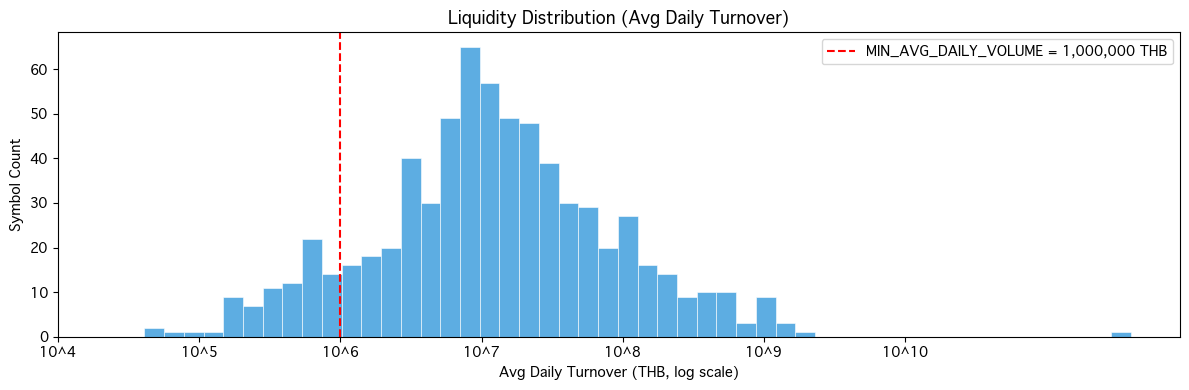

In [4]:
# Section 3 — Liquidity distribution histogram
if not symbol_keys:
    display(HTML("<div style='color:orange;font-weight:bold;'>⚠ DATA NOT AVAILABLE — data/raw/ is empty. Run fetch_history.py first.</div>"))
else:
    turnovers: list[float] = []
    for key in symbol_keys:
        try:
            df = raw_store.load(key)
            avg_close = float(df["close"].mean())
            avg_vol = float(df["volume"].mean())
            if avg_close > 0 and avg_vol > 0:
                turnovers.append(avg_close * avg_vol)
        except Exception:
            continue

    log_turnover = np.log10([t for t in turnovers if t > 0])
    log_threshold = np.log10(MIN_AVG_DAILY_VOLUME)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.hist(log_turnover, bins=50, color="#5DADE2", edgecolor="white", linewidth=0.4)
    ax.axvline(log_threshold, color="red", linewidth=1.5, linestyle="--",
               label=f"MIN_AVG_DAILY_VOLUME = {MIN_AVG_DAILY_VOLUME:,.0f} THB")

    # Relabel x-axis with original THB values
    tick_vals = [4, 5, 6, 7, 8, 9, 10]
    ax.set_xticks(tick_vals)
    ax.set_xticklabels([f"10^{v}" for v in tick_vals])
    ax.set_xlabel("Avg Daily Turnover (THB, log scale)")
    ax.set_ylabel("Symbol Count")
    ax.set_title("Liquidity Distribution (Avg Daily Turnover)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    below_threshold = sum(1 for t in turnovers if t < MIN_AVG_DAILY_VOLUME)
    pct = below_threshold / len(turnovers) * 100 if turnovers else 0.0
    display(HTML(
        f"<span style='font-size:14px;'><b>Symbols below MIN_AVG_DAILY_VOLUME threshold:</b> "
        f"<span style='color:#e74c3c;font-weight:bold;'>{below_threshold}</span>"
        f" / {len(turnovers)} ({pct:.1f}%)</span>"
    ))


## ส่วนที่ 4: การตรวจสอบ Survivorship Bias / ความสมบูรณ์ของข้อมูล

**หมายเหตุสำคัญ:** การตรวจสอบในส่วนนี้คือ **Fetch Completeness Audit** ไม่ใช่การพิสูจน์ว่าไม่มี Survivorship Bias อย่างสมบูรณ์

- `settfex.get_stock_list()` ดึงรายชื่อ symbol จาก SET API รวมถึง symbol ที่ถูก Delist แล้ว  
- การเปรียบเทียบ `symbols.json` กับ `data/raw/` แสดงให้เห็นว่า symbol ใดที่มีข้อมูลดิบและ symbol ใดที่ดึงข้อมูลไม่สำเร็จ  
- การป้องกัน Survivorship Bias ที่แท้จริงมาจาก Dated Universe Snapshots ใน `data/universe/` ที่สร้างโดย `build_universe.py` ซึ่งใช้เฉพาะข้อมูลที่มีอยู่ ณ วันที่กำหนดเท่านั้น (ไม่มี look-ahead)
- Metadata การ Delist (วันที่ถูก Suspend/Delist) ยังไม่มีใน `settfex` ใน Phase 1 นี้
- ยังไม่รวมหุ้นบางตัวที่มีการเปลี่ยนชื่อย่อ

In [5]:
# Section 4 — Survivorship bias / fetch completeness audit
symbols_json_path = settings.data_dir / "universe" / "symbols.json"

if not symbols_json_path.exists():
    display(HTML("<div style='color:orange;font-weight:bold;'>⚠ DATA NOT AVAILABLE — data/universe/symbols.json not found. Run build_universe.py first.</div>"))
elif not symbol_keys:
    display(HTML("<div style='color:orange;font-weight:bold;'>⚠ DATA NOT AVAILABLE — data/raw/ is empty. Run fetch_history.py first.</div>"))
else:
    raw_json = json.loads(symbols_json_path.read_text())
    universe_candidates: list[str] = raw_json.get("symbols", [])
    raw_set = set(symbol_keys)
    candidate_set = set(universe_candidates)

    fetched = candidate_set & raw_set
    missing_from_raw = candidate_set - raw_set
    extra_in_raw = raw_set - candidate_set  # fetched but not in current universe JSON

    display(HTML(f"""
<table style="border-collapse:collapse;font-size:14px;font-family:monospace;">
  <tr style="background:#f5f5f5">
    <th style="text-align:left;padding:6px 24px 6px 8px;color:#555;">Metric</th>
    <th style="text-align:right;padding:6px 8px;color:#555;">Count</th>
  </tr>
  <tr><td style="padding:5px 24px 5px 8px;color:#888;">Universe candidates (symbols.json)</td>
      <td style="padding:5px 8px;text-align:right;font-weight:bold;">{len(universe_candidates):,}</td></tr>
  <tr style="background:#fafafa"><td style="padding:5px 24px 5px 8px;color:#888;">Symbols with raw parquet data</td>
      <td style="padding:5px 8px;text-align:right;font-weight:bold;">{len(raw_set):,}</td></tr>
  <tr><td style="padding:5px 24px 5px 8px;color:#2ecc71;">Successfully fetched (intersection)</td>
      <td style="padding:5px 8px;text-align:right;font-weight:bold;color:#2ecc71;">{len(fetched):,}</td></tr>
  <tr style="background:#fafafa"><td style="padding:5px 24px 5px 8px;color:#e74c3c;">Missing from raw (fetch failures)</td>
      <td style="padding:5px 8px;text-align:right;font-weight:bold;color:#e74c3c;">{len(missing_from_raw):,}</td></tr>
  <tr><td style="padding:5px 24px 5px 8px;color:#888;">Extra in raw (not in current JSON)</td>
      <td style="padding:5px 8px;text-align:right;font-weight:bold;">{len(extra_in_raw):,}</td></tr>
</table>
"""))

    if missing_from_raw:
        sample_rows = "".join(
            f"<tr><td style='padding:3px 8px;font-family:monospace;'>{s}</td></tr>"
            for s in sorted(missing_from_raw)[:10]
        )
        display(HTML(f"""
<details open style="margin-top:12px;">
  <summary style="cursor:pointer;font-weight:bold;">Sample symbols with fetch failures (first 10)</summary>
  <table style="border-collapse:collapse;font-size:13px;margin-top:6px;">{sample_rows}</table>
</details>
"""))

    # Top-10 symbols by calendar history length
    history_lengths: list[tuple[str, float]] = []
    for key in symbol_keys:
        try:
            df = raw_store.load(key)
            close = df["close"].dropna()
            if len(close) < 2:
                continue
            first_dt = close.index[0]
            last_dt = close.index[-1]
            years_hist = (last_dt - first_dt).days / 365.25
            history_lengths.append((key, years_hist))
        except Exception:
            continue
    history_lengths.sort(key=lambda x: x[1], reverse=True)

    top_rows = "".join(
        f"<tr style='{'background:#fafafa' if i % 2 else ''}'>"
        f"<td style='padding:5px 24px 5px 8px;font-family:monospace;'>{sym}</td>"
        f"<td style='padding:5px 8px;text-align:right;font-family:monospace;'>{yrs:.1f}</td></tr>"
        for i, (sym, yrs) in enumerate(history_lengths[:10])
    )
    display(HTML(f"""
<p style="margin-top:16px;font-weight:bold;">Top-10 Symbols by Longest Price History</p>
<table style="border-collapse:collapse;font-size:14px;">
  <tr style="background:#f5f5f5">
    <th style="text-align:left;padding:6px 24px 6px 8px;">Symbol</th>
    <th style="text-align:right;padding:6px 8px;">History (years)</th>
  </tr>
  {top_rows}
</table>
"""))


Metric,Count
Universe candidates (symbols.json),704
Symbols with raw parquet data,694
Successfully fetched (intersection),693
Missing from raw (fetch failures),11
Extra in raw (not in current JSON),1


SET:B-WORK
SET:F&D
SET:L&E
SET:M-CHAI
SET:M-PAT
SET:M-STOR
SET:NFC
SET:Q-CON
SET:S&J
SET:SE-ED


Symbol,History (years)
SET:B52,45.3
SET:KWC,45.3
SET:GYT,38.9
SET:FE,38.7
SET:WACOAL,38.7
SET:OCC,38.7
SET:BTNC,38.5
SET:TTI,38.3
SET:TPCS,37.9
SET:OHTL,37.8


## ส่วนที่ 5: ขนาด Universe ตามช่วงเวลา

แสดงจำนวน Symbol ที่ผ่านเกณฑ์ Phase 1.4 (ราคา, ปริมาณการซื้อขาย, ความครอบคลุม) ในแต่ละวัน Rebalance  
ข้อมูลนี้โหลดจาก Dated Universe Snapshots ใน `data/universe/`  
เป้าหมาย: Universe ≥ 400 symbol ในช่วงปัจจุบัน

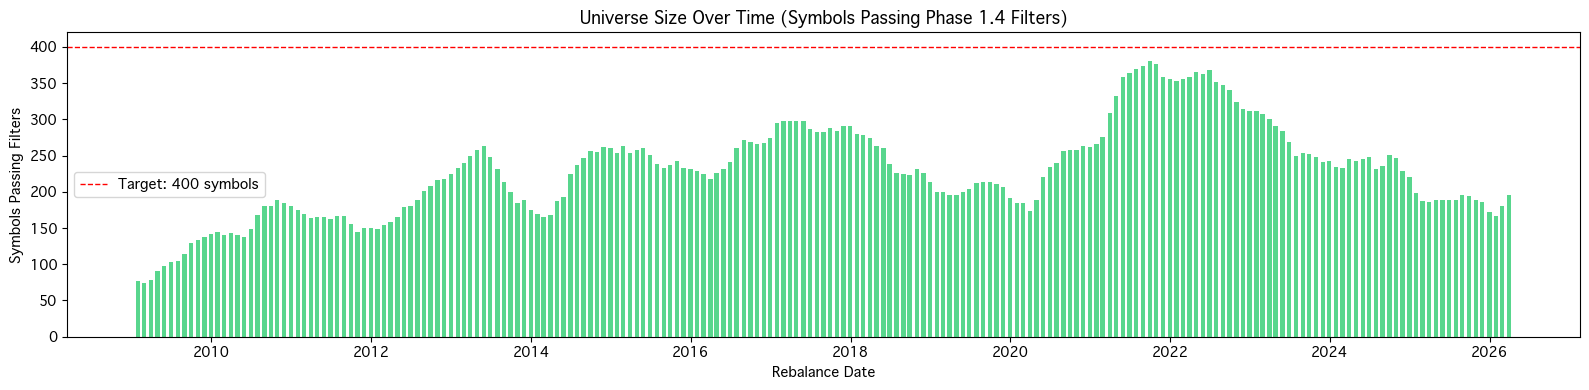

Total snapshots,207
Latest universe size,196 symbols (2026-03-31)
Average universe size,229 symbols
Snapshots with ≥400 symbols,0 / 207


In [6]:
# Section 5 — Universe size over time
if not snapshot_keys:
    display(HTML("<div style='color:orange;font-weight:bold;'>⚠ DATA NOT AVAILABLE — no universe snapshots found in data/universe/. Run build_universe.py first.</div>"))
else:
    size_series: dict[str, int] = {}
    for key in snapshot_keys:
        try:
            snap_df = universe_store.load(key)
            date_str = key.split("/", 1)[-1]  # strip "universe/" prefix
            size_series[date_str] = len(snap_df)
        except Exception:
            continue

    sizes = pd.Series(size_series).sort_index()
    sizes.index = pd.to_datetime(sizes.index)

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.bar(sizes.index, sizes.values, width=20, color="#58D68D", edgecolor="none")
    ax.axhline(400, color="red", linewidth=1.0, linestyle="--", label="Target: 400 symbols")
    ax.set_xlabel("Rebalance Date")
    ax.set_ylabel("Symbols Passing Filters")
    ax.set_title("Universe Size Over Time (Symbols Passing Phase 1.4 Filters)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    ge400 = int((sizes >= 400).sum())
    display(HTML(f"""
<table style="border-collapse:collapse;font-size:14px;font-family:monospace;">
  <tr><td style="padding:4px 24px 4px 0;color:#888;">Total snapshots</td>
      <td style="padding:4px 0;font-weight:bold;">{len(sizes)}</td></tr>
  <tr><td style="padding:4px 24px 4px 0;color:#888;">Latest universe size</td>
      <td style="padding:4px 0;font-weight:bold;">{sizes.iloc[-1]} symbols ({sizes.index[-1].date()})</td></tr>
  <tr><td style="padding:4px 24px 4px 0;color:#888;">Average universe size</td>
      <td style="padding:4px 0;font-weight:bold;">{sizes.mean():.0f} symbols</td></tr>
  <tr><td style="padding:4px 24px 4px 0;color:#888;">Snapshots with &ge;400 symbols</td>
      <td style="padding:4px 0;font-weight:bold;">{ge400} / {len(sizes)}</td></tr>
</table>
"""))


## ส่วนที่ 6: สรุปความครอบคลุมของข้อมูล

จัดกลุ่ม Symbol ตามข้อมูลราคาย้อนหลัง (Calendar History Length):  
- **≥ 15 ปี** — ข้อมูลครบตาม `LOOKBACK_YEARS`
- **10–15 ปี** — ข้อมูลบางส่วน
- **< 10 ปี** — ข้อมูลสั้น (จดทะเบียนใหม่หรือดึงข้อมูลได้น้อย)

ความยาวประวัติคำนวณจาก `(วันที่มีราคาสุดท้าย − วันที่มีราคาแรก) / 365.25`

In [7]:
# Section 6 — Coverage summary (calendar history length buckets)
if not symbol_keys:
    display(HTML("<div style='color:orange;font-weight:bold;'>⚠ DATA NOT AVAILABLE — data/raw/ is empty. Run fetch_history.py first.</div>"))
else:
    bucket_full: list[str] = []    # >= 15Y
    bucket_partial: list[str] = [] # 10-15Y
    bucket_short: list[str] = []   # < 10Y
    coverage_fracs: list[float] = []

    for key in symbol_keys:
        try:
            df = raw_store.load(key)
            close = df["close"].dropna()
            if len(close) < 2:
                bucket_short.append(key)
                coverage_fracs.append(0.0)
                continue

            # Calendar history length
            first_dt = close.index[0]
            last_dt = close.index[-1]
            history_years = (last_dt - first_dt).days / 365.25

            if history_years >= 15:
                bucket_full.append(key)
            elif history_years >= 10:
                bucket_partial.append(key)
            else:
                bucket_short.append(key)

            # Coverage fraction (consistent with UniverseBuilder.filter)
            total_bars = len(df["close"])
            valid_bars = int(df["close"].notna().sum())
            window = min(total_bars, LOOKBACK_YEARS * 252)
            coverage_fracs.append(valid_bars / window if window > 0 else 0.0)
        except Exception:
            bucket_short.append(key)
            coverage_fracs.append(0.0)

    total = len(symbol_keys)
    display(HTML(f"""
<p style="font-weight:bold;margin-bottom:6px;">Coverage Summary (Calendar History Length)</p>
<table style="border-collapse:collapse;font-size:14px;font-family:monospace;">
  <tr style="background:#f5f5f5">
    <th style="text-align:left;padding:6px 24px 6px 8px;">Bucket</th>
    <th style="text-align:right;padding:6px 12px;">Count</th>
    <th style="text-align:right;padding:6px 8px;">Share</th>
  </tr>
  <tr>
    <td style="padding:5px 24px 5px 8px;">&ge; 15 years (full LOOKBACK)</td>
    <td style="padding:5px 12px;text-align:right;font-weight:bold;color:#2ecc71;">{len(bucket_full):,}</td>
    <td style="padding:5px 8px;text-align:right;">{len(bucket_full)/total*100:.1f}%</td>
  </tr>
  <tr style="background:#fafafa">
    <td style="padding:5px 24px 5px 8px;">10–15 years (partial)</td>
    <td style="padding:5px 12px;text-align:right;font-weight:bold;color:#f39c12;">{len(bucket_partial):,}</td>
    <td style="padding:5px 8px;text-align:right;">{len(bucket_partial)/total*100:.1f}%</td>
  </tr>
  <tr>
    <td style="padding:5px 24px 5px 8px;">&lt; 10 years (short)</td>
    <td style="padding:5px 12px;text-align:right;font-weight:bold;color:#e74c3c;">{len(bucket_short):,}</td>
    <td style="padding:5px 8px;text-align:right;">{len(bucket_short)/total*100:.1f}%</td>
  </tr>
  <tr style="border-top:2px solid #ddd;">
    <td style="padding:5px 24px 5px 8px;font-weight:bold;">Total</td>
    <td style="padding:5px 12px;text-align:right;font-weight:bold;">{total:,}</td>
    <td style="padding:5px 8px;text-align:right;">100.0%</td>
  </tr>
</table>
"""))

    if coverage_fracs:
        median_cov = float(np.median(coverage_fracs))
        below = sum(1 for c in coverage_fracs if c < MIN_DATA_COVERAGE)
        cov_color = "#2ecc71" if median_cov >= MIN_DATA_COVERAGE else "#e74c3c"
        display(HTML(f"""
<table style="border-collapse:collapse;font-size:14px;font-family:monospace;margin-top:10px;">
  <tr><td style="padding:4px 24px 4px 0;color:#888;">Median coverage</td>
      <td style="padding:4px 0;font-weight:bold;color:{cov_color};">{median_cov:.2%}</td></tr>
  <tr><td style="padding:4px 24px 4px 0;color:#888;">MIN_DATA_COVERAGE threshold</td>
      <td style="padding:4px 0;font-weight:bold;">{MIN_DATA_COVERAGE:.2%}</td></tr>
  <tr><td style="padding:4px 24px 4px 0;color:#888;">Symbols below threshold</td>
      <td style="padding:4px 0;font-weight:bold;color:#e74c3c;">{below} / {total} ({below/total*100:.1f}%)</td></tr>
</table>
"""))


Bucket,Count,Share
≥ 15 years (full LOOKBACK),391,56.3%
10–15 years (partial),95,13.7%
< 10 years (short),208,30.0%
Total,694,100.0%


Median coverage,112.10%
MIN_DATA_COVERAGE threshold,80.00%
Symbols below threshold,0 / 694 (0.0%)


## ส่วนที่ 7: การตรวจสอบการปรับราคาเงินปันผล (Price Adjustment Verification)

ตรวจสอบว่าข้อมูล OHLCV ถูกบันทึกอย่างถูกต้องในสองโหมดการปรับราคา:

| โหมด | ไดเรกทอรี | คำอธิบาย |
|---|---|---|
| `splits` | `data/raw/splits/` | ปรับราคาเฉพาะ Stock Split (legacy — Phase 1.6) |
| `dividends` | `data/raw/dividends/` | ปรับราคารวมเงินปันผล / Total Return (Phase 1.8+) |

**หลักการ:** เมื่อบริษัทจ่ายเงินปันผล ราคาหุ้นจะลดลงในวัน Ex-Dividend ประมาณเท่ากับเงินปันผลนั้น  
ด้วย `Adjustment.SPLITS` ราคาย้อนหลังไม่มีการปรับ — ทำให้ผลตอบแทนดูแย่กว่าความเป็นจริง  
ด้วย `Adjustment.DIVIDENDS` ราคาย้อนหลังทั้งหมดจะถูกปรับลงเพื่อสะท้อน Total Return ที่นักลงทุนจริงๆ ได้รับ

**หมายเหตุ:** tvkit v0.11.0 ยังไม่ถูก Release — ราคาในทั้งสองโหมดอาจเหมือนกันจนกว่าจะอัปเกรด

In [ ]:
# Section 7 — Price Adjustment Verification
splits_store = ParquetStore(settings.data_dir / "raw" / "splits")
dividends_store = ParquetStore(settings.data_dir / "raw" / "dividends")

splits_keys: list[str] = splits_store.list_keys()
dividends_keys: list[str] = dividends_store.list_keys()

# Display store inventory
display(HTML(f"""
<table style="border-collapse:collapse;font-size:14px;font-family:monospace;">
  <tr style="background:#f5f5f5">
    <th style="text-align:left;padding:6px 24px 6px 8px;color:#555;">Store</th>
    <th style="text-align:left;padding:6px 8px;color:#555;">Path</th>
    <th style="text-align:right;padding:6px 8px;color:#555;">Symbols</th>
  </tr>
  <tr>
    <td style="padding:5px 24px 5px 8px;">splits</td>
    <td style="padding:5px 24px 5px 8px;color:#888;">data/raw/splits/</td>
    <td style="padding:5px 8px;text-align:right;font-weight:bold;">{len(splits_keys):,}</td>
  </tr>
  <tr style="background:#fafafa">
    <td style="padding:5px 24px 5px 8px;">dividends</td>
    <td style="padding:5px 24px 5px 8px;color:#888;">data/raw/dividends/</td>
    <td style="padding:5px 8px;text-align:right;font-weight:bold;">{len(dividends_keys):,}</td>
  </tr>
</table>
"""))

# Try to load a high-dividend symbol for comparison
# Priority: ADVANC > KBANK > PTT > first symbol available in both stores
_CANDIDATES = ["SET:ADVANC", "SET:KBANK", "SET:PTT", "SET:CPALL", "SET:SCB"]
_sample_symbol: str | None = None
_df_splits: "pd.DataFrame | None" = None
_df_dividends: "pd.DataFrame | None" = None

for sym in _CANDIDATES:
    try:
        _df_splits = splits_store.load(sym)
        _df_dividends = dividends_store.load(sym)
        _sample_symbol = sym
        break
    except KeyError:
        continue

if _sample_symbol is None and splits_keys:
    # Fall back to first symbol available in splits store
    try:
        _sample_symbol = splits_keys[0]
        _df_splits = splits_store.load(_sample_symbol)
        try:
            _df_dividends = dividends_store.load(_sample_symbol)
        except KeyError:
            _df_dividends = None
    except Exception:
        pass

if _df_splits is None:
    display(HTML("<div style='color:orange;font-weight:bold;'>⚠ DATA NOT AVAILABLE — data/raw/splits/ is empty. Run: uv run python scripts/fetch_history.py --adjustment splits</div>"))
else:
    # Align indexes for comparison
    close_splits = _df_splits["close"].dropna().copy()
    close_splits.index = pd.DatetimeIndex(close_splits.index).tz_localize(None)

    fig, axes = plt.subplots(1, 2 if _df_dividends is not None else 1, figsize=(16, 4))
    if _df_dividends is None:
        axes = [axes]

    # Plot 1 — splits-adjusted close
    ax0 = axes[0]
    ax0.plot(close_splits.index, close_splits.values, color="#2980b9", linewidth=0.8, label="splits-adjusted")
    ax0.set_title(f"{_sample_symbol} — Splits-Adjusted Close")
    ax0.set_xlabel("Date")
    ax0.set_ylabel("Price (THB)")
    ax0.legend()
    ax0.grid(True, alpha=0.3)

    if _df_dividends is not None:
        close_dividends = _df_dividends["close"].dropna().copy()
        close_dividends.index = pd.DatetimeIndex(close_dividends.index).tz_localize(None)

        ax1 = axes[1]
        ax1.plot(close_splits.index, close_splits.values, color="#2980b9", linewidth=0.8,
                 label="splits", alpha=0.7)
        ax1.plot(close_dividends.index, close_dividends.values, color="#e74c3c", linewidth=0.8,
                 label="dividends", alpha=0.7)
        ax1.set_title(f"{_sample_symbol} — Splits vs Dividend-Adjusted Close")
        ax1.set_xlabel("Date")
        ax1.set_ylabel("Price (THB)")
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Check divergence
        common_idx = close_splits.index.intersection(close_dividends.index)
        if len(common_idx) > 0:
            pct_diff = (
                (close_dividends.loc[common_idx] - close_splits.loc[common_idx]).abs()
                / close_splits.loc[common_idx].abs()
            ).mean()
            if pct_diff < 0.001:
                display(HTML(
                    "<div style='color:#f39c12;font-weight:bold;margin-top:6px;'>"
                    "⚠ NOTE: Prices are nearly identical — tvkit&lt;0.11.0 does not yet support "
                    "the adjustment parameter. Both series reflect split-adjusted data. "
                    "Re-run fetch_history.py after upgrading to tvkit&gt;=0.11.0 for genuine "
                    "dividend-adjusted prices.</div>"
                ))
            else:
                mean_ret_splits = float(close_splits.pct_change().mean())
                mean_ret_div = float(close_dividends.pct_change().mean())
                display(HTML(f"""
<table style="border-collapse:collapse;font-size:14px;font-family:monospace;margin-top:8px;">
  <tr style="background:#f5f5f5">
    <th style="text-align:left;padding:6px 24px 6px 8px;">Metric</th>
    <th style="text-align:right;padding:6px 8px;">Splits</th>
    <th style="text-align:right;padding:6px 8px;">Dividends</th>
  </tr>
  <tr>
    <td style="padding:5px 24px 5px 8px;color:#888;">Mean daily return</td>
    <td style="padding:5px 8px;text-align:right;">{mean_ret_splits:.4%}</td>
    <td style="padding:5px 8px;text-align:right;font-weight:bold;color:#2ecc71;">{mean_ret_div:.4%}</td>
  </tr>
  <tr style="background:#fafafa">
    <td style="padding:5px 24px 5px 8px;color:#888;">Mean abs pct difference</td>
    <td colspan="2" style="padding:5px 8px;text-align:right;">{pct_diff:.2%}</td>
  </tr>
</table>
"""))

    plt.tight_layout()
    plt.show()

    display(HTML(f"<b>Sample symbol:</b> {_sample_symbol} &nbsp;|&nbsp; "
                 f"<b>Splits store:</b> {len(splits_keys):,} symbols &nbsp;|&nbsp; "
                 f"<b>Dividends store:</b> {len(dividends_keys):,} symbols"))

# Section 7 PASS gate: dividends store must have at least 1 symbol
_s7_pass = len(dividends_keys) >= 1
_s7_label = "✓ PASS" if _s7_pass else "✗ FAIL"
_s7_color = "#1a7a45" if _s7_pass else "#a93226"
_s7_bg = "#eafaf1" if _s7_pass else "#fdf2f2"
_s7_note = (
    f"data/raw/dividends/ contains {len(dividends_keys):,} symbol(s)" if _s7_pass
    else "data/raw/dividends/ is empty — run: uv run python scripts/fetch_history.py --adjustment dividends"
)
display(HTML(f"""
<div style="margin-top:14px;padding:12px 16px;background:{_s7_bg};
            border-left:5px solid {_s7_color};border-radius:4px;font-size:14px;">
  <span style="font-weight:bold;color:{_s7_color};">{_s7_label}</span>
  &nbsp;— Section 7 gate: dividends store populated &nbsp;|&nbsp;
  <span style="color:{_s7_color};">{_s7_note}</span>
</div>
"""))

## ส่วนที่ 8: การตรวจสอบและอนุมัติ (Sign-off)

ตรวจสอบเกณฑ์ทั้ง 6 ข้อ — ต้องผ่านทุกข้อก่อนเริ่ม Phase 2 (Signal Research)

| # | เกณฑ์ | ค่าที่ต้องการ |
|---|---|---|
| 1 | จำนวน Raw Symbol | ≥ 400 |
| 2 | ประวัติดัชนี SET:SET | ≥ `LOOKBACK_YEARS × 252` bars |
| 3 | Median coverage | ≥ `MIN_DATA_COVERAGE` |
| 4 | Median avg daily turnover | ≥ `MIN_AVG_DAILY_VOLUME` THB |
| 5 | Universe snapshots | ≥ 1 snapshot |
| 6 | Symbol ที่มี 0 valid bars | = 0 |

In [ ]:
# Section 8 — Sign-off: PASS/FAIL for all 6 exit criteria
PASS = "✓ PASS"
FAIL = "✗ FAIL"
NO_DATA = "✗ FAIL (NO DATA)"

results: list[tuple[str, str, str]] = []

# Criterion 1 — Raw symbol count >= 400
raw_count = len(symbol_keys)
c1 = PASS if raw_count >= 400 else (FAIL if raw_count > 0 else NO_DATA)
results.append(("1", "Raw symbol count &ge; 400", f"{c1}  [{raw_count}]"))

# Criterion 2 — SET:SET index history >= LOOKBACK_YEARS * 252 bars
required_bars = LOOKBACK_YEARS * 252
try:
    index_df = raw_store.load("SET:SET")
    index_bars = int(index_df["close"].notna().sum())
    c2 = PASS if index_bars >= required_bars else FAIL
    results.append(("2", f"SET:SET bars &ge; {required_bars}", f"{c2}  [{index_bars}]"))
except KeyError:
    results.append(("2", f"SET:SET bars &ge; {required_bars}", f"{NO_DATA}  [not found]"))

# Criterion 3 — Median data coverage >= MIN_DATA_COVERAGE
cov_list: list[float] = []
zero_valid: list[str] = []
for key in symbol_keys:
    try:
        df_c = raw_store.load(key)
        total_bars_c = len(df_c["close"])
        valid_bars_c = int(df_c["close"].notna().sum())
        window_c = min(total_bars_c, LOOKBACK_YEARS * 252)
        cov = valid_bars_c / window_c if window_c > 0 else 0.0
        cov_list.append(cov)
        if valid_bars_c == 0:
            zero_valid.append(key)
    except Exception:
        cov_list.append(0.0)
        zero_valid.append(key)

if cov_list:
    med_cov = float(np.median(cov_list))
    c3 = PASS if med_cov >= MIN_DATA_COVERAGE else FAIL
    results.append(("3", f"Median coverage &ge; {MIN_DATA_COVERAGE:.0%}",
                    f"{c3}  [{med_cov:.2%}]"))
else:
    results.append(("3", f"Median coverage &ge; {MIN_DATA_COVERAGE:.0%}", NO_DATA))

# Criterion 4 — Median avg daily turnover >= MIN_AVG_DAILY_VOLUME
to_list: list[float] = []
for key in symbol_keys:
    try:
        df_t = raw_store.load(key)
        avg_c = float(df_t["close"].mean())
        avg_v = float(df_t["volume"].mean())
        if avg_c > 0 and avg_v > 0:
            to_list.append(avg_c * avg_v)
    except Exception:
        continue

if to_list:
    med_to = float(np.median(to_list))
    c4 = PASS if med_to >= MIN_AVG_DAILY_VOLUME else FAIL
    results.append(("4", f"Median turnover &ge; {MIN_AVG_DAILY_VOLUME:,.0f} THB",
                    f"{c4}  [{med_to:,.0f} THB]"))
else:
    results.append(("4", f"Median turnover &ge; {MIN_AVG_DAILY_VOLUME:,.0f} THB", NO_DATA))

# Criterion 5 — Universe snapshots present
snap_count = len(snapshot_keys)
c5 = PASS if snap_count >= 1 else (FAIL if symbol_keys else NO_DATA)
results.append(("5", "Universe snapshots &ge; 1", f"{c5}  [{snap_count}]"))

# Criterion 6 — No symbol with 0 valid bars
zero_count = len(zero_valid)
if not symbol_keys:
    c6 = NO_DATA
elif zero_count == 0:
    c6 = PASS
else:
    c6 = FAIL
results.append(("6", "No symbol with 0 valid bars", f"{c6}  [{zero_count} symbols]"))

# Build HTML sign-off table
all_pass = all(v.startswith("✓") for _, _, v in results)

def _row_style(verdict: str) -> str:
    if verdict.startswith("✓"):
        return "background:#eafaf1;"
    return "background:#fdf2f2;"

def _verdict_color(verdict: str) -> str:
    return "#1a7a45" if verdict.startswith("✓") else "#a93226"

rows_html = "".join(
    f"<tr style='{_row_style(verdict)}'>"
    f"<td style='padding:8px 12px;text-align:center;font-weight:bold;width:32px;'>{num}</td>"
    f"<td style='padding:8px 20px 8px 12px;'>{criterion}</td>"
    f"<td style='padding:8px 12px;font-weight:bold;font-family:monospace;"
    f"color:{_verdict_color(verdict)};'>{verdict}</td></tr>"
    for num, criterion, verdict in results
)

banner_bg = "#d5f5e3" if all_pass else "#fadbd8"
banner_color = "#1a7a45" if all_pass else "#a93226"
banner_icon = "✅" if all_pass else "❌"
banner_title = "ALL CHECKS PASSED — PHASE 1 SIGN-OFF COMPLETE" if all_pass else "SOME CHECKS FAILED — DO NOT PROCEED TO PHASE 2"
banner_body = (
    "Data quality validated. Ready for Phase 2 (Signal Research)."
    if all_pass else
    "Fix the failing checks, then re-run this notebook to confirm."
)

display(HTML(f"""
<div style="font-family:sans-serif;max-width:720px;">
  <h3 style="margin-bottom:10px;">PHASE 1.7 — DATA QUALITY SIGN-OFF</h3>
  <table style="border-collapse:collapse;font-size:14px;width:100%;">
    <tr style="background:#f5f5f5;">
      <th style="padding:8px 12px;text-align:center;width:32px;">#</th>
      <th style="padding:8px 20px 8px 12px;text-align:left;">Criterion</th>
      <th style="padding:8px 12px;text-align:left;">Result</th>
    </tr>
    {rows_html}
  </table>
  <div style="margin-top:16px;padding:14px 18px;background:{banner_bg};
              border-left:5px solid {banner_color};border-radius:4px;">
    <div style="font-size:16px;font-weight:bold;color:{banner_color};">
      {banner_icon} {banner_title}
    </div>
    <div style="margin-top:4px;color:{banner_color};font-size:13px;">{banner_body}</div>
  </div>
</div>
"""))